# Example 1 -- Measurement-induced universal squeezer

This notebook builds a CV-ZX diagram from scratch, simplifies it rule by rule (so you can see what each rewrite rule does), and then compares that against running the fully automated `optimize()` pipeline.

**The physical setup.** A single mode (the one we care about) is mixed on a beamsplitter with a second, freshly-prepared ancilla mode. One of the beamsplitter's two outputs is thrown away by a homodyne measurement, producing a classical outcome `m`. The surviving mode then receives a displacement correction whose amount depends on `m` -- this is "feedforward": a later gate's parameter is computed from an earlier measurement's outcome, rather than being fixed in advance.

**The claim we're checking.** This gadget -- prepare an ancilla, beamsplitter, measure, feedforward-correct -- is a standard trick for implementing a *squeezing* gate using only measurement and linear optics (no genuinely nonlinear element). The paper this example is drawn from claims the gadget is equivalent to a single squeezing gate `Sq(sin(theta))`, where `theta` is the beamsplitter angle. We'll build the gadget as a CV-ZX diagram, apply the calculus's rewrite rules to it, and see what it collapses down to.

**New to CV-ZX calculus / this codebase?** A few terms that come up throughout:
- **`QSpider`/`PSpider`** -- the two families of "spiders" (generalized nodes) the calculus is built from, one per quadrature basis (position/momentum). Each carries a polynomial *phase* (a `ZxPoly`) and can have any number of input/output wires.
- **`ZxPoly`** -- a real polynomial (in one variable) used as a spider's phase, e.g. `ZxPoly({1: 2.0})` is `2*x`. A spider with the all-zero polynomial (`ZxPoly({})`) and exactly one input/output is the calculus's identity wire.
- **`TensorDiagram`** -- diagrams placed side by side (in parallel), like `⊗` in tensor-network notation.
- **`CompositionDiagram`** -- diagrams chained one after another (in sequence), like `∘`.
- A rewrite **rule** looks for a specific local pattern in a diagram and replaces it with something simpler representing the same physical operation -- see the rule-by-rule walkthrough below.

In [1]:
from sympy import sqrt, sin, tan, I, symbols

# Diagram building blocks -- QSpider/PSpider (the two spider colors), ZxPoly
# (polynomial phases), and TensorDiagram/CompositionDiagram (parallel/sequential
# composition). flatten_tensor/flatten_composition merge nested Tensor/Compose
# containers into flat ones -- purely for a cleaner picture when visualizing,
# they don't change what the diagram represents.
from cvzx.ir.base import CompositionDiagram, PSpider, QSpider, TensorDiagram, ZxPoly, flatten_composition, flatten_tensor
# The physical gates: BeamsplitterGate/DisplacementGate/SqueezingGate are all
# "compact" gates -- convenience wrappers that `.expand()` into their underlying
# spider decomposition when needed.
from cvzx.ir.gates import BeamsplitterGate, DisplacementGate, SqueezingGate
from cvzx.visualization.core import visualize

# The zero-phase (trivial) polynomial -- used below for identity wires and the
# idealized (infinite-squeezing) ancilla state, both of which are "no phase"
# spiders.
zero_phase = ZxPoly({})

## Build the diagram

We build the gadget directly as a `Diagram` (rather than starting from a circuit description) so we can see exactly how each physical step maps onto CV-ZX pieces. It has three stages, composed in sequence:

- **Stage 0**: the input mode -- represented as a bare identity wire, `QSpider(1, 1, zero_phase)` -- tensored (placed side by side) with a freshly-prepared ancilla mode. The ancilla is built as `PSpider(0, 1, zero_phase)` (a zero-phase *state*: no inputs, one output -- an idealized, infinitely-squeezed vacuum state) followed by an identity wire, just to keep both lanes the same length for the `Tensor`.
- **Stage 1**: both modes pass through the beamsplitter, `BeamsplitterGate(theta, ...).expand()` -- `.expand()` swaps the compact `BeamsplitterGate` box for its actual spider/contraction decomposition, which is what the rewrite rules below operate on.
- **Stage 2**: one beamsplitter output is measured (`measurement`, a `QSpider(1, 0, ...)` effect -- one input, zero outputs, so it "consumes" that mode and produces a classical outcome we call `m`); the other output receives a `DisplacementGate` whose amount is `feedforward`-derived from `m`.

**Feedforward bookkeeping.** `measurement.id` is the CV-ZX graph's unique node id for the measurement leaf. The displacement gate below is built with `feedforward=True`, `measurement_ids={measurement.id}`, and `param_measurement_map={theta: {measurement.id}}` -- this is how the diagram records *which* measurement a later gate's parameter depends on, so later rewriting can correctly account for that dependency instead of treating the gate as if its parameter were already known.

measurement leaf id (measurement.id): 21


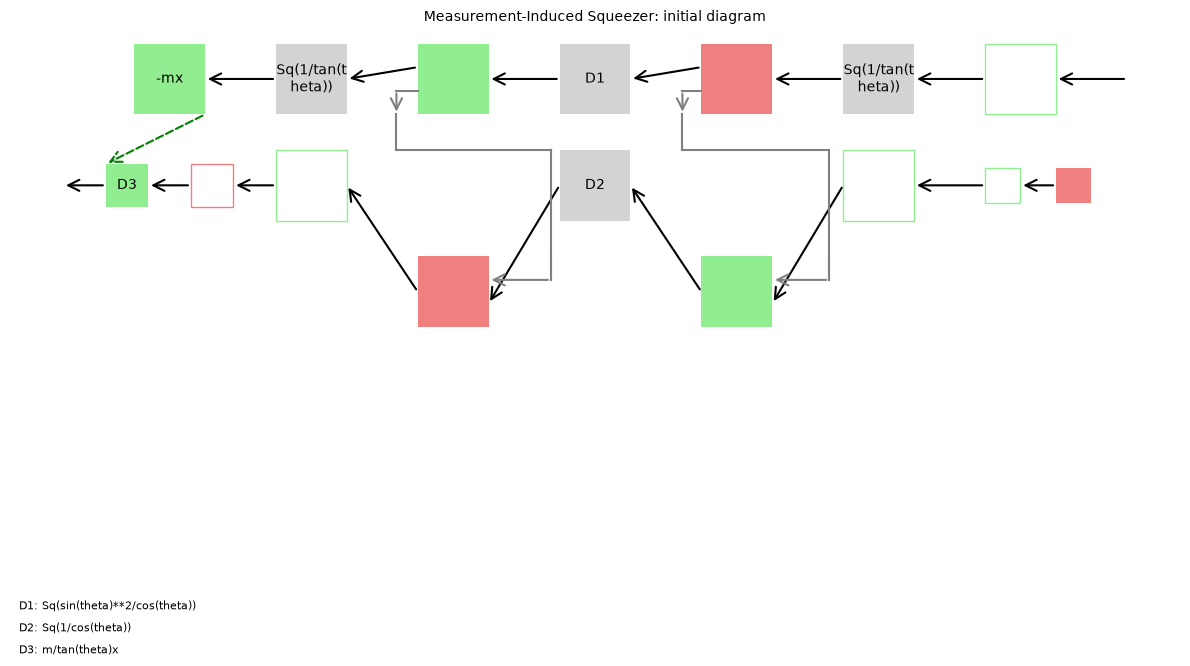

In [2]:
m, theta = symbols("m theta", real=True)

# .expand() turns the compact BeamsplitterGate box into its actual spider
# decomposition (squeezing gates + spider contractions) -- see the diagram's
# repr a couple of cells down for what this looks like.
beamsplitter_expanded = BeamsplitterGate(theta, True).expand()

# The measurement effect: a QSpider with one input, zero outputs (an "effect",
# the dual of a state). Its phase -m*x records that its outcome is called m.
measurement = QSpider(1, 0, ZxPoly({1: -m}), parametric=True)

# Stage 0: input mode (identity wire) tensored with a fresh ancilla state.
stage0 = TensorDiagram([
    QSpider(1, 1, zero_phase),
    CompositionDiagram([PSpider(0, 1, zero_phase), QSpider(1, 1, zero_phase)]),
])

# Stage 1: both modes through the beamsplitter.
stage1 = TensorDiagram([beamsplitter_expanded])

# Stage 2: measure one output; feedforward-correct the other with a
# displacement whose amount depends on the measurement outcome m.
stage2 = TensorDiagram([
    measurement,
    DisplacementGate(
        I * m / (sqrt(2) * tan(theta)),
        True,   # parametric: the displacement amount is symbolic
        True,   # feedforward: this gate's amount depends on an earlier measurement
        {measurement.id},             # measurement_ids: which measurement(s) it depends on
        {theta: {measurement.id}},    # param_measurement_map: symbol -> measurement id(s)
    ).expand(),
])

# Stages 0-1-2 in sequence make up the full gadget.
gadget = CompositionDiagram([stage0, stage1, stage2])

# flatten_tensor/flatten_composition just tidy up nested containers for a
# cleaner picture -- see the imports cell above.
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in gadget.diagrams])
fig_gadget = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: initial diagram")

print("measurement leaf id (measurement.id):", measurement.id)

### Sanity check: one mode in, one mode out

The gadget consumes a fresh ancilla and a measurement outcome internally, but from the *outside* it should still look like a single-mode gate: one input wire (the mode being squeezed) and one output wire (the same mode, squeezed). Let's confirm that directly from the diagram's own arity before doing any simplification.

In [3]:
print(f"gadget: {gadget.num_inputs} input(s) -> {gadget.num_outputs} output(s)")

gadget: 1 input(s) -> 1 output(s)


## The paper's claimed reduced form

The paper's claim is that the whole gadget above -- ancilla, beamsplitter, measurement, feedforward displacement -- is equivalent to a single `SqueezingGate`, with a squeezing parameter that's a function of the beamsplitter angle `theta`. We build that claimed target here so we have something to visually compare the simplified gadget against, below.

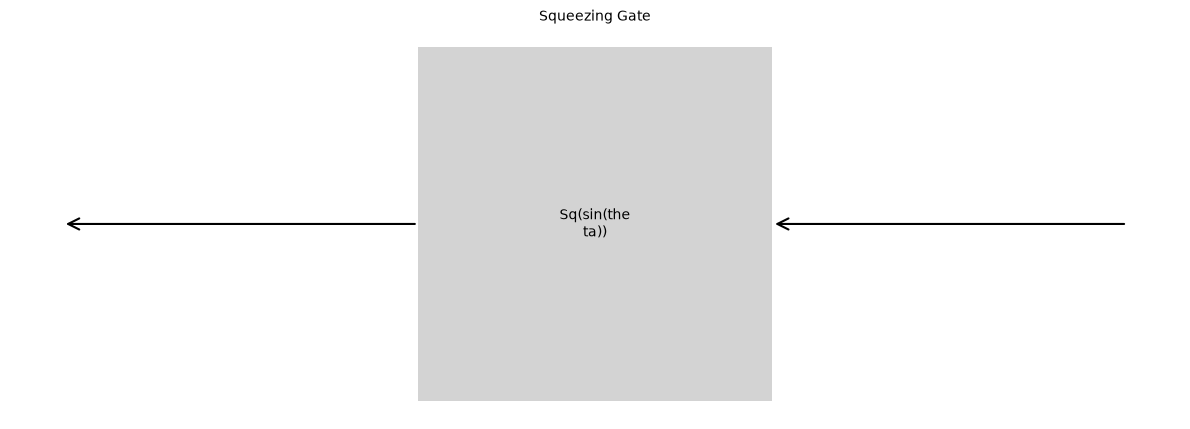

In [4]:
# The paper's claimed closed-form equivalent -- for visual comparison only.
target_diagram = SqueezingGate(sin(theta), True)
fig_target = visualize(target_diagram, "Squeezing Gate")

## Run the optimization pipeline incrementally

Simplifying `gadget` down to (something like) a single squeezing gate requires several rewrite rules, each targeting a different local pattern. `assume_infinite_squeezing=True` is required throughout: the ancilla and the measurement above are only meaningful as *idealized* (infinite-squeezing) eigenstates, and it's exactly that idealized regime that `CopyRule` and `TerminalAbsorptionRule`'s squeezing sub-case rely on to apply at all.

We'll run the rewrite rules one at a time below, visualizing the diagram after each one, so you can see exactly what each rule changes. Each rule works the same way: `rule.match(graph)` looks for its pattern in the graph (returning an empty list if nothing matches) and `rule.apply_rule(graph)` rewrites every match it finds, in place.

Afterwards we'll run the `optimize()` function, which repeats this whole process automatically -- including *multiple rounds* of it, since simplifying one part of the diagram can expose further simplifications elsewhere -- until nothing changes any more.

### 1. `CopyRule`

`CopyRule` copies a 0-arity state or effect (like our ancilla's `PSpider(0, 1, ...)`) through an adjacent spider with several legs, producing one copy per leg. The beamsplitter's spider decomposition (from `.expand()`) has exactly this shape where it meets our ancilla, so this rule fans the ancilla state out across it.

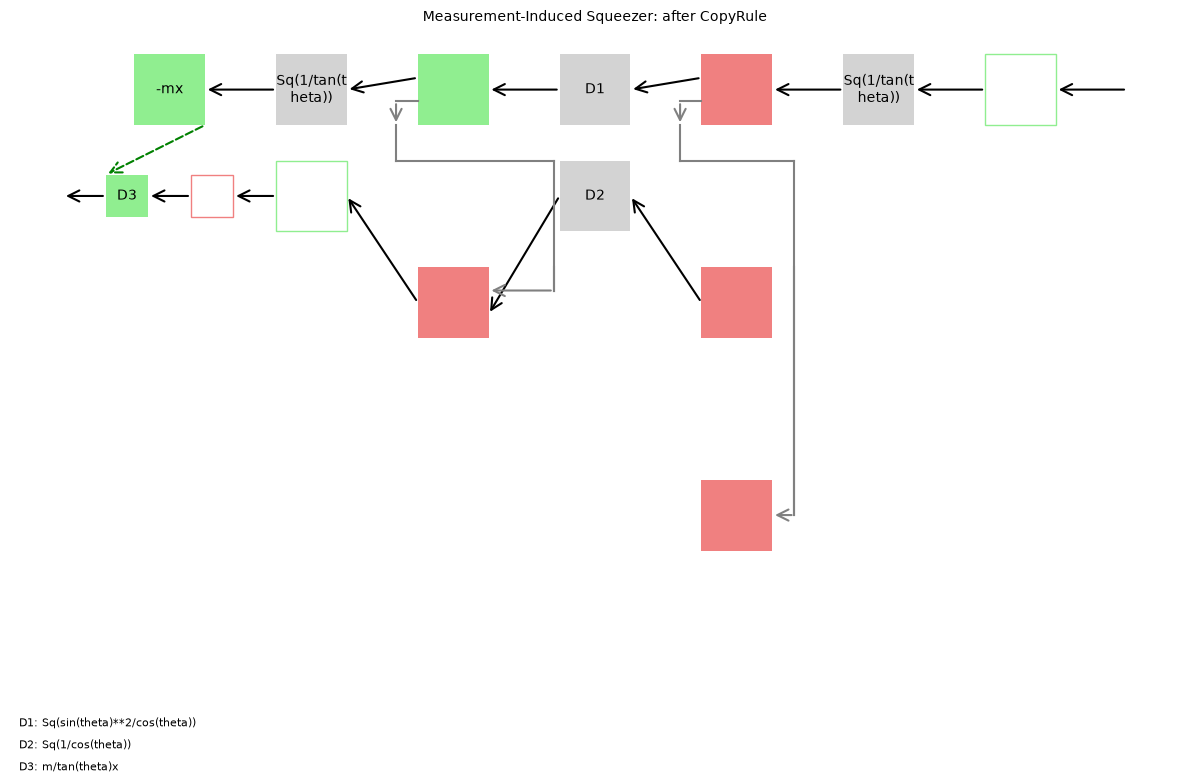

In [5]:
from cvzx.backends.nx.rules import IdentityRule, PassthroughRule, TerminalAbsorptionRule, CopyRule, FusionRule, ChainReductionRule
from cvzx.backends.nx.graph import to_diagram, to_graph

# Every rule works on the graph representation: to_graph()/to_diagram() convert
# between the tree-shaped Diagram form (easy to build/read) and the graph form
# (what the rewrite rules actually search and mutate).
copy_rule = CopyRule()
graph_after_copy = to_graph(gadget)
copy_rule.apply_rule(graph_after_copy)
diag_after_copy = to_diagram(graph_after_copy)
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in diag_after_copy.diagrams])
fig_after_copy = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: after CopyRule")

### 2. `FusionRule`

`FusionRule` merges two adjacent, same-color spiders connected by a single wire into one spider, adding their phases together. `CopyRule` just introduced several copied spiders next to each other -- this pass fuses the ones of matching color back down.

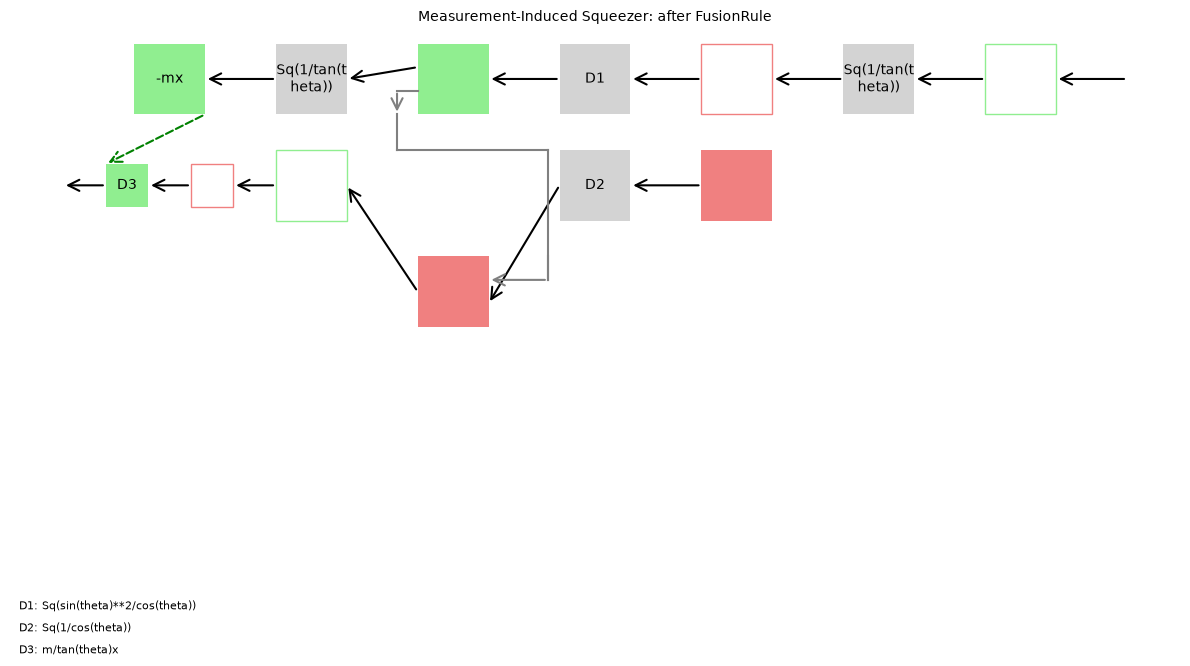

In [6]:
fusion_rule = FusionRule()
graph_after_fusion1 = to_graph(diag_after_copy)
fusion_rule.apply_rule(graph_after_fusion1)
diag_after_fusion1 = to_diagram(graph_after_fusion1)
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in diag_after_fusion1.diagrams])
fig_after_fusion1 = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: after FusionRule")

### 3. `TerminalAbsorptionRule`

`TerminalAbsorptionRule` absorbs a gate sitting right next to a *terminal* -- a spider with arity `(1, 0)` (an effect, like our measurement) or `(0, 1)` (a state, like our ancilla) -- directly into that terminal's own phase, eliminating the gate. This is where the measurement effect starts "swallowing" the squeezing/rotation gates next to it.

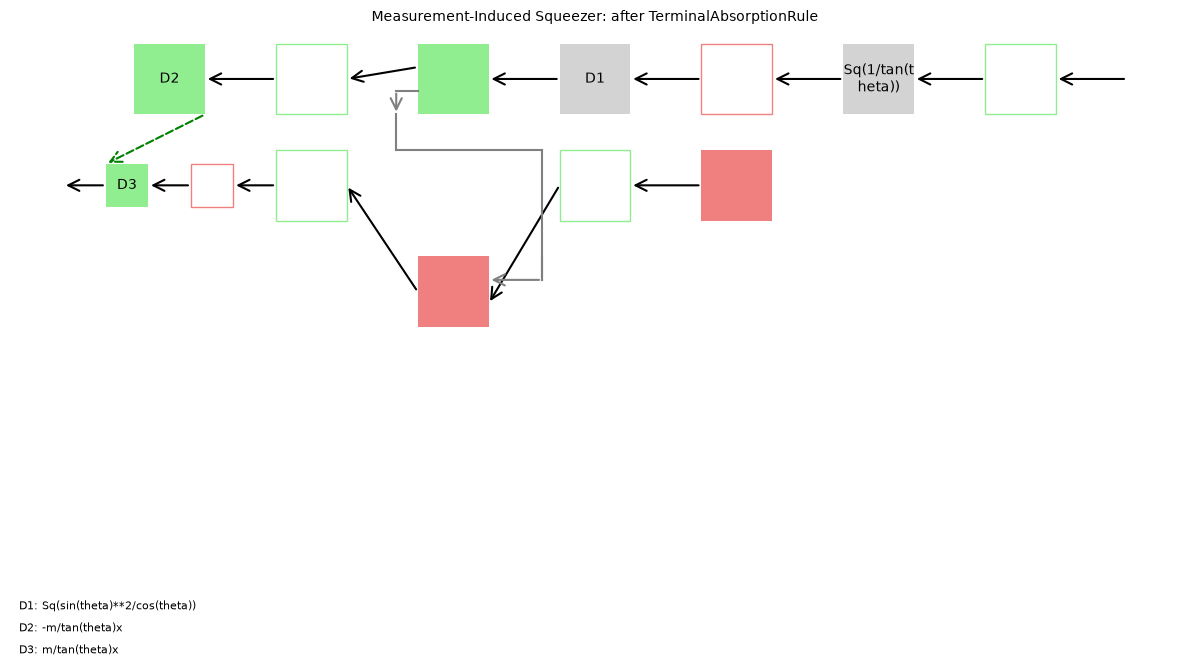

In [7]:
absorption_rule = TerminalAbsorptionRule(True)
graph_after_absorption = to_graph(diag_after_fusion1)
absorption_rule.apply_rule(graph_after_absorption)

diag_after_absorption = to_diagram(graph_after_absorption)
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in diag_after_absorption.diagrams])
fig_after_absorption = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: after TerminalAbsorptionRule")

### 4. `FusionRule`, again

Absorbing gates into the terminal in the last step can expose *new* same-color spider pairs that are now adjacent (and weren't before). We run `FusionRule` again to catch those. This time we also print `fusion_rule_again.match(graph_after_fusion2)` first, so you can see what a rule's match actually looks like -- a list of dicts describing each spot the rule found its pattern, before `apply_rule` rewrites them.

FusionRule found 2 match(es):
  {'shape': 'composition', 'first_id': 21, 'second_id': 204, 'spider_type': 'QSpider', 'identity_chain': [207], 'consumed_second_input': 0}
  {'shape': 'composition', 'first_id': 198, 'second_id': 205, 'spider_type': 'PSpider', 'identity_chain': [202], 'consumed_second_input': 1}


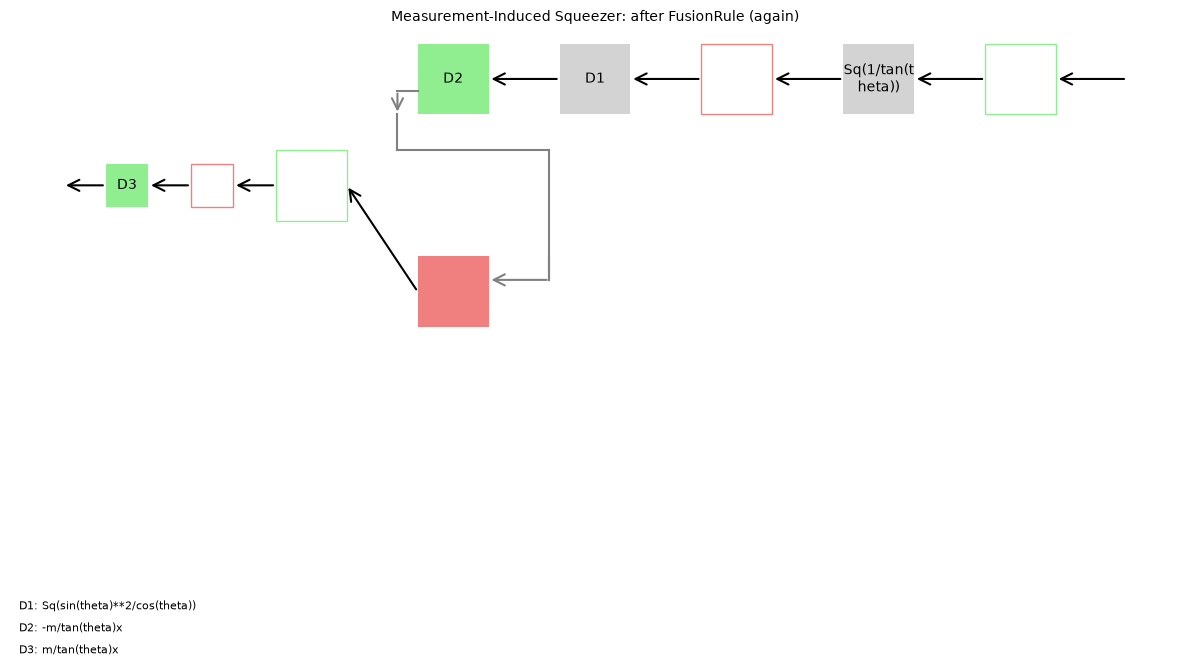

In [8]:
fusion_rule_again = FusionRule()
graph_after_fusion2 = to_graph(diag_after_absorption)

matches = fusion_rule_again.match(graph_after_fusion2)
print(f"FusionRule found {len(matches)} match(es):")
for match in matches:
    print(" ", match)

fusion_rule_again.apply_rule(graph_after_fusion2)

diag_after_fusion2 = to_diagram(graph_after_fusion2)
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in diag_after_fusion2.diagrams])
fig_after_fusion2 = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: after FusionRule (again)")

### 5. `PassthroughRule`

At this point the diagram contains a `ContractedDiagram` that *looks* like a genuine partial trace but mathematically isn't one: it's two different-color spiders linked by a single wire, where one side is a zero-phase spider with exactly one "kept" input and output. A zero-phase spider forces all its legs to carry the same value, so a shape like this is really just a plain wire in disguise. `PassthroughRule` recognizes this and rewrites it into an explicit `Swap` plus the surviving spider -- unlocking the wire underneath so later rules (like the next one) can chase straight through it.

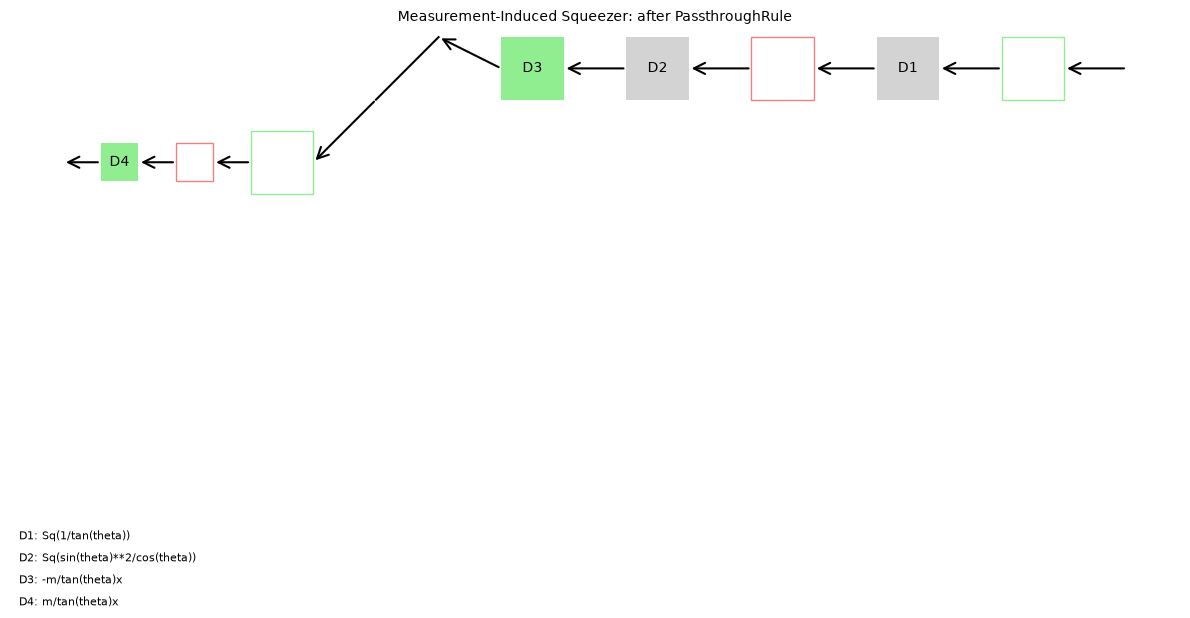

In [9]:
passthrough_rule = PassthroughRule()
graph_after_passthrough = to_graph(diag_after_fusion2)
passthrough_rule.apply_rule(graph_after_passthrough)

diag_after_passthrough = to_diagram(graph_after_passthrough)
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in diag_after_passthrough.diagrams])
fig_after_passthrough = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: after PassthroughRule")

### 6. `ChainReductionRule`

`ChainReductionRule` fuses adjacent gates of the *same type* using their own algebraic composition law -- e.g. two squeezing gates `Sq(tau1) . Sq(tau2) -> Sq(tau1 * tau2)`, two displacements add, two rotations add their angles, and so on. It can chase straight through identity wires and `Swap`s (like the one `PassthroughRule` just introduced) to find gates that are adjacent in spirit even if something trivial sits physically between them. This is the step that finally collapses the remaining chain down to (close to) a single squeezing gate.

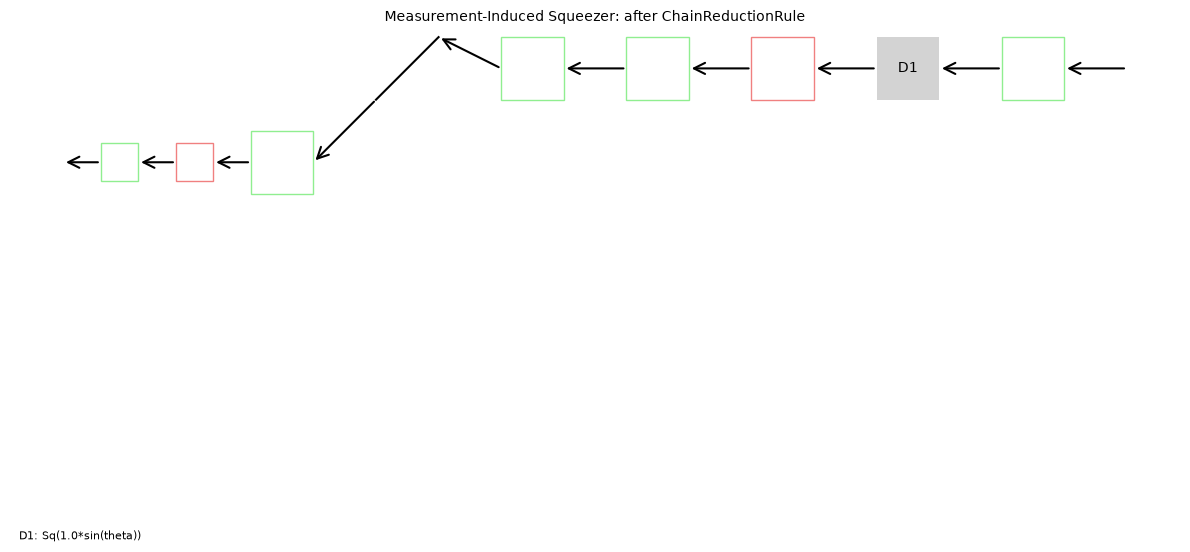

In [10]:
chain_reduction_rule = ChainReductionRule()
graph_after_chain_reduction = to_graph(diag_after_passthrough)
chain_reduction_rule.apply_rule(graph_after_chain_reduction)

diag_after_chain_reduction = to_diagram(graph_after_chain_reduction)
to_plot = CompositionDiagram([flatten_tensor(diag) for diag in diag_after_chain_reduction.diagrams])
fig_after_chain_reduction = visualize(flatten_composition(to_plot), "Measurement-Induced Squeezer: after ChainReductionRule")

## Tidy up the picture

The rules above leave some `VoidDiagram` filler and container nesting behind (bookkeeping placeholders for slots that got consumed along the way). `normalize_diagram` rewrites the diagram into a canonical, alternating form purely for a cleaner picture -- it doesn't do any further algebraic simplification.

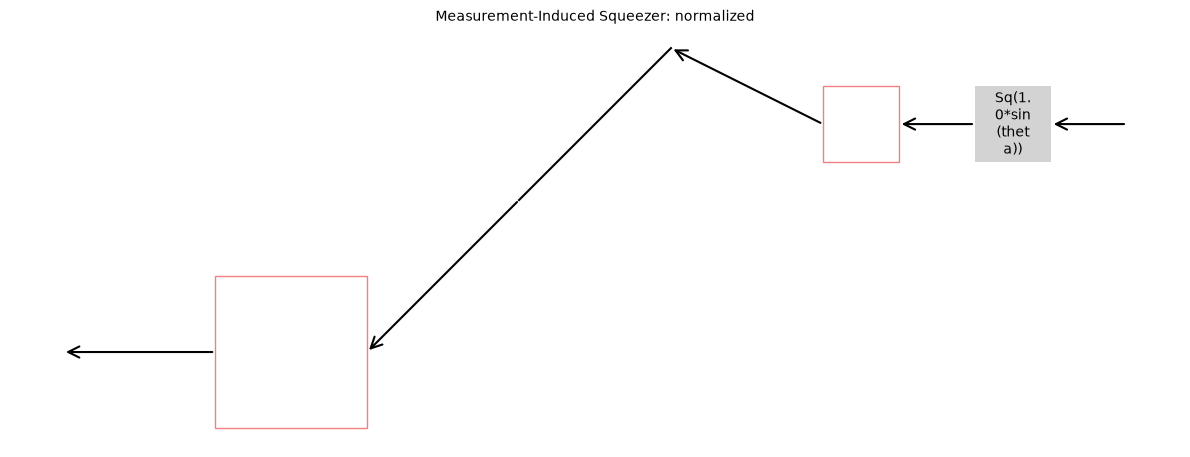

In [11]:
from cvzx.passes.normalize import normalize_diagram

diag_normalized = normalize_diagram(diag_after_chain_reduction)
fig_normalized = visualize(flatten_composition(diag_normalized), "Measurement-Induced Squeezer: normalized")

This is the paper's claimed shape -- a squeezing gate, with some leftover wiring around it -- reached by running each rule by hand, one pass each. Compare the picture above to `fig_target` (the paper's claimed shape) a few cells up.

## Now let's run the optimization pipeline

Doing this one rule at a time, one pass each, is useful for seeing what's happening -- but in practice you'd just call `optimize()`. It runs every rule (in a fixed order tuned so each one feeds the next) to a fixed point, and repeats that over multiple rounds -- since simplifying part of the diagram in one round can expose further simplifications only visible in the next -- until nothing changes any more. That's why its result below can end up simpler than what one pass each of the rules above produced.

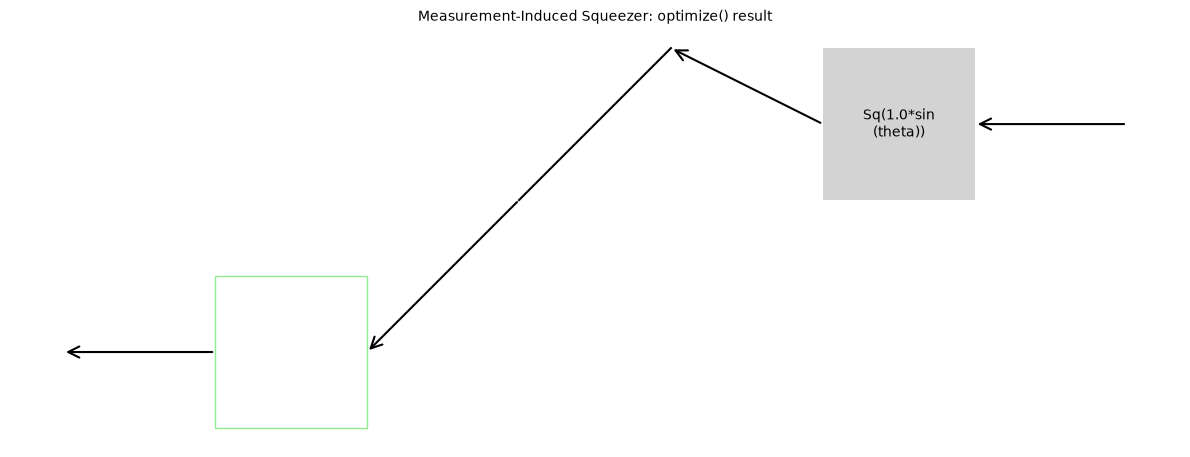

In [12]:
from cvzx.passes.optimize import optimize
from cvzx.config import Backend  # lets you pick the graph backend, e.g. optimize(..., backend=Backend.RX)

result = optimize(gadget, backend=Backend.NETWORKX, assume_infinite_squeezing=True)
fig_optimized = visualize(result.diagram, "Measurement-Induced Squeezer: optimize() result")

`optimize()`'s multiple rounds (each one: simplify to a fixed point, then re-normalize and check whether anything further is now possible) catch reductions that a single manual pass of each rule, run once, doesn't -- which is why this result is cleaner than the hand-driven version above.

## Benchmarking the reduction

The pictures above make it clear `optimize()` produced something much simpler than `gadget` -- but "simpler" can be made precise. `cvzx.utils.metrics.compare_metrics` measures exactly how much smaller a diagram got, across several independent axes: spider/gate/generator counts (the ones that matter most -- see the dev guide's "Benchmarking optimization quality" page, `docs/source/dev_guide/benchmarks.md`, for why bookkeeping leaves like identity wires and `VoidDiagram` placeholders are deliberately excluded from these), raw node/edge totals, a non-Clifford-analogue phase count, and stage depth.

`depth` shows `None` for `gadget` itself: `BeamsplitterGate(...).expand()` already produced a `ContractedDiagram` back in the "Build the diagram" step above, and `normalize_diagram` (which depth is measured via) conservatively leaves any `ContractedDiagram` unchanged rather than guessing a stage count for it. `result.diagram` has no such container left, so its depth is well-defined.

In [13]:
from cvzx.utils.metrics import compare_metrics

comparison = compare_metrics(gadget, result.diagram)

print(f"{'metric':<20s}{'before':>8s}{'after':>8s}{'reduction':>12s}")
for field in ("spiders", "gates", "generators", "nodes", "edges", "non_clifford_phases", "depth"):
    before = getattr(comparison.before, field)
    after = getattr(comparison.after, field)
    reduction = comparison.reduction(field)
    reduction_str = f"{reduction:.0%}" if reduction is not None else "n/a"
    print(f"{field:<20s}{before!s:>8s}{after!s:>8s}{reduction_str:>12s}")

metric                before   after   reduction
spiders                    7       0        100%
gates                      4       1         75%
generators                11       2         82%
nodes                     28      17         39%
edges                     16       9         44%
non_clifford_phases        0       0         n/a
depth                   None       3         n/a


Every metric drops for this example: `optimize()` genuinely eliminates the ancilla and the measurement effect, folding everything down to the single surviving `SqueezingGate`. That's not guaranteed in general, though -- under `assume_infinite_squeezing=True` specifically, `optimize()` unconditionally expands every surviving two-mode gate into its own multi-spider decomposition so `CopyRule` can see the copy-spider structure it needs, which can make `spiders`/`generators` *increase* even when real simplification also happened elsewhere (a compact-gate count that goes down is the more reliable signal in that case). See the dev guide's worked `four_mode_csum` example for a case where exactly that happens.